# PPG HR Micro Power Analysis

Notebook này phân tích bộ log **V7 dual-MCU hardware sync** tại `log/pgg_hr_log_v7/`.

Mục tiêu:
- Đo **effective DAQ sampling interval** từ dữ liệu thật thay vì giả định theo cấu hình danh định
- Ghép **target.csv** và **daq.csv** theo thứ tự burst để phân tích từng cửa sổ xử lý `HIGH`
- Tích phân **total active energy** gồm cả **power tail**
- Ước lượng riêng **TinyML invoke energy** bằng `invoke_time_us` từ target log
- So sánh mức đóng góp năng lượng của **DSP/feature extraction** và **TinyML**


In [1]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import ppg_hr_micro_analysis_lib as micro_lib
micro_lib = importlib.reload(micro_lib)

micro_lib.apply_publication_style()

LOG_ROOT = PROJECT_ROOT / "log" / "pgg_hr_log_v7"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "ppg_hr_micro_analysis_v7"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Log root:", LOG_ROOT)
print("Output dir:", OUTPUT_DIR)


Project root: c:\ml\kaggle-ml-basics
Log root: c:\ml\kaggle-ml-basics\log\pgg_hr_log_v7
Output dir: c:\ml\kaggle-ml-basics\artifacts\ppg_hr_micro_analysis_v7


In [2]:
analysis = micro_lib.analyze_dataset(LOG_ROOT)
run_summary_df = analysis["run_summary"].copy()
burst_df = analysis["burst_df"].copy()
mode_summary_df = analysis["mode_summary"].copy()

print(f"Loaded {len(run_summary_df)} runs.")
display(run_summary_df.round(2))


Loaded 6 runs.


,mode_id,mode_name,run_name,n_target_windows,n_high_windows,n_bursts,alignment_ok,daq_avg_power_mw,daq_median_power_mw,quiet_baseline_mw,dt_mean_us,dt_median_us,dt_min_us,dt_max_us,infer_capture_rate_pct,mean_total_active_energy_uj,mean_ai_energy_est_uj,mean_ai_energy_fraction_pct,mean_tail_duration_us
0,2,adaptive,adaptive_1,37,21,21,True,257.34,256.0,256.0,3290.63,3299.0,3030.0,7077.0,80.95,1506.54,34.09,2.17,17575.95
1,2,adaptive,adaptive_2,42,17,17,True,250.55,250.0,250.0,3292.36,3299.0,3030.0,7077.0,64.71,1402.73,32.43,2.26,19827.12
2,1,fixed_high,fixed_high_1,18,18,18,True,255.12,252.0,252.0,3276.25,3298.0,3030.0,7077.0,55.56,1407.36,33.39,2.37,16849.94
3,1,fixed_high,fixed_high_2,17,17,17,True,259.26,256.0,256.0,3275.46,3298.0,3030.0,7077.0,35.29,1378.04,34.81,2.50,16283.65
4,0,fixed_normal,fixed_normal_1,17,0,0,True,255.09,252.0,252.0,3275.82,3298.0,3030.0,7075.0,0.00,NaN,NaN,NaN,NaN
5,0,fixed_normal,fixed_normal_2,18,0,0,True,255.37,252.0,252.0,3276.94,3298.0,3030.0,7080.0,0.00,NaN,NaN,NaN,NaN


In [3]:
display(mode_summary_df.round(2))

slow_summary_df = mode_summary_df[mode_summary_df["slow_path_bursts"].fillna(0) > 0].copy()

print("Key V7 findings")
print(f"- Effective DAQ median interval: {mode_summary_df['dt_median_us'].mean():.1f} us")
print(f"- Adaptive mean total active energy per burst: {slow_summary_df.loc[slow_summary_df['mode_name'] == 'adaptive', 'total_active_energy_uj_mean'].iloc[0]:.2f} uJ")
print(f"- Fixed High mean total active energy per burst: {slow_summary_df.loc[slow_summary_df['mode_name'] == 'fixed_high', 'total_active_energy_uj_mean'].iloc[0]:.2f} uJ")
print(f"- Adaptive weighted AI energy fraction: {slow_summary_df.loc[slow_summary_df['mode_name'] == 'adaptive', 'ai_energy_fraction_pct_weighted'].iloc[0]:.2f}%")
print(f"- Fixed High weighted AI energy fraction: {slow_summary_df.loc[slow_summary_df['mode_name'] == 'fixed_high', 'ai_energy_fraction_pct_weighted'].iloc[0]:.2f}%")


,mode_name,n_runs,daq_avg_power_mw,daq_median_power_mw,quiet_baseline_mw,dt_mean_us,dt_median_us,dt_min_us,dt_max_us,n_bursts,...,feature_pin_width_us_mean,infer_pin_width_us_mean,seed_duration_us_mean,tail_duration_us_mean,integration_duration_us_mean,infer_capture_rate_burst_pct,total_active_energy_uj_sum,ai_energy_est_uj_sum,dsp_energy_est_uj_sum,ai_energy_fraction_pct_weighted
0,adaptive,2,253.95,253.0,253.0,3291.50,3299.0,3030.0,7077.0,38,...,7200.21,2604.03,10411.89,18583.05,28994.95,73.68,55483.65,1267.17,54216.48,2.28
1,fixed_high,2,257.19,254.0,254.0,3275.86,3298.0,3030.0,7077.0,35,...,6961.80,1601.97,9035.00,16574.89,25609.89,45.71,48759.03,1192.85,47566.18,2.45
2,fixed_normal,2,255.23,252.0,252.0,3276.38,3298.0,3030.0,7077.5,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Key V7 findings
- Effective DAQ median interval: 3298.3 us
- Adaptive mean total active energy per burst: 1460.10 uJ
- Fixed High mean total active energy per burst: 1393.12 uJ
- Adaptive weighted AI energy fraction: 2.28%
- Fixed High weighted AI energy fraction: 2.45%


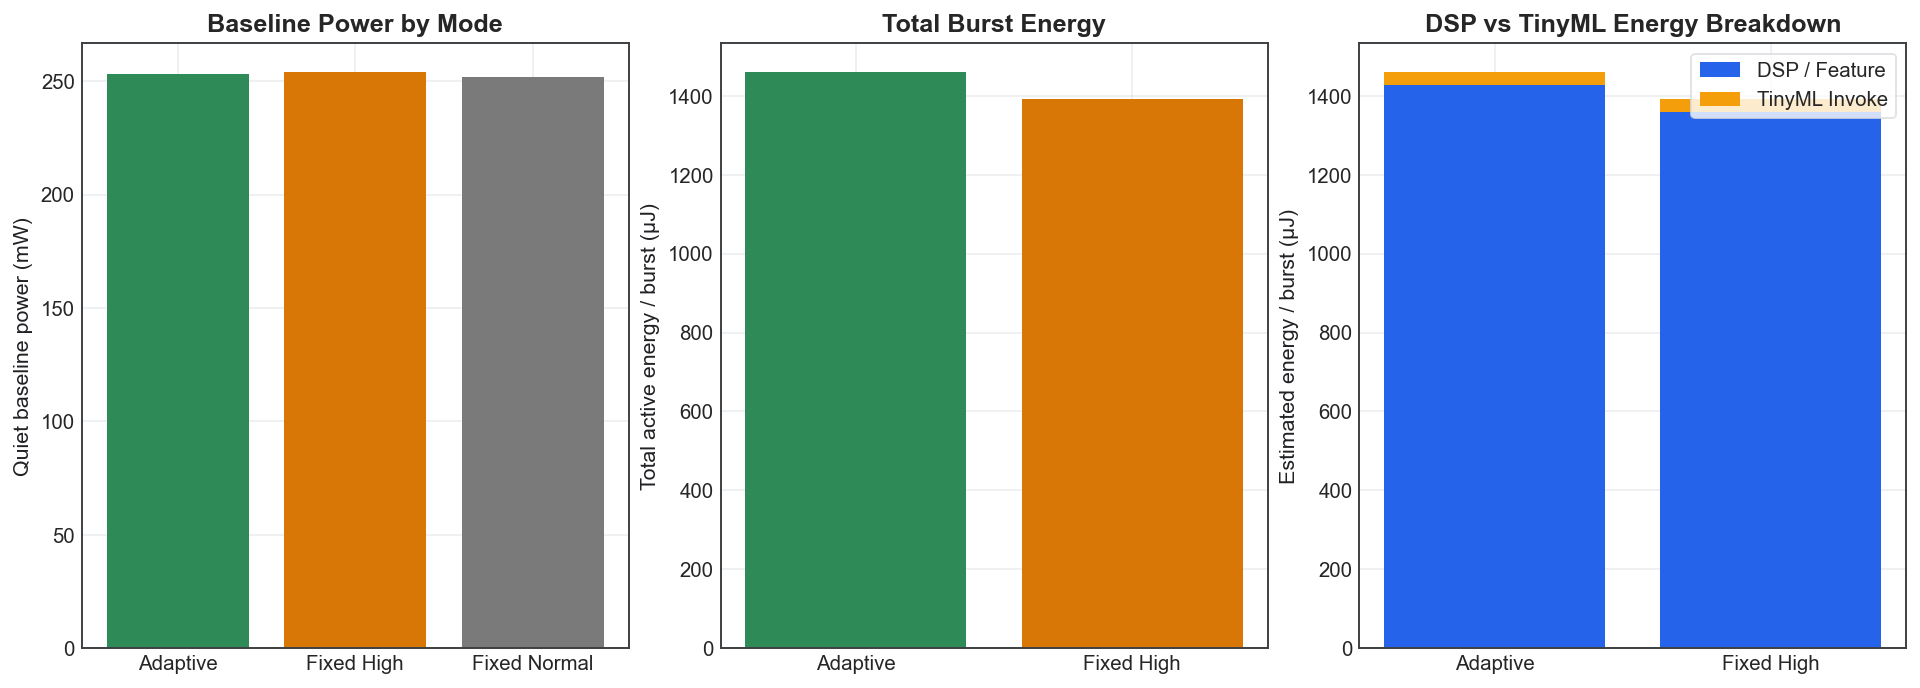

In [4]:
fig = micro_lib.plot_micro_energy_dashboard(mode_summary_df)
fig.savefig(OUTPUT_DIR / "micro_energy_dashboard_v7.png", bbox_inches="tight")
plt.show()


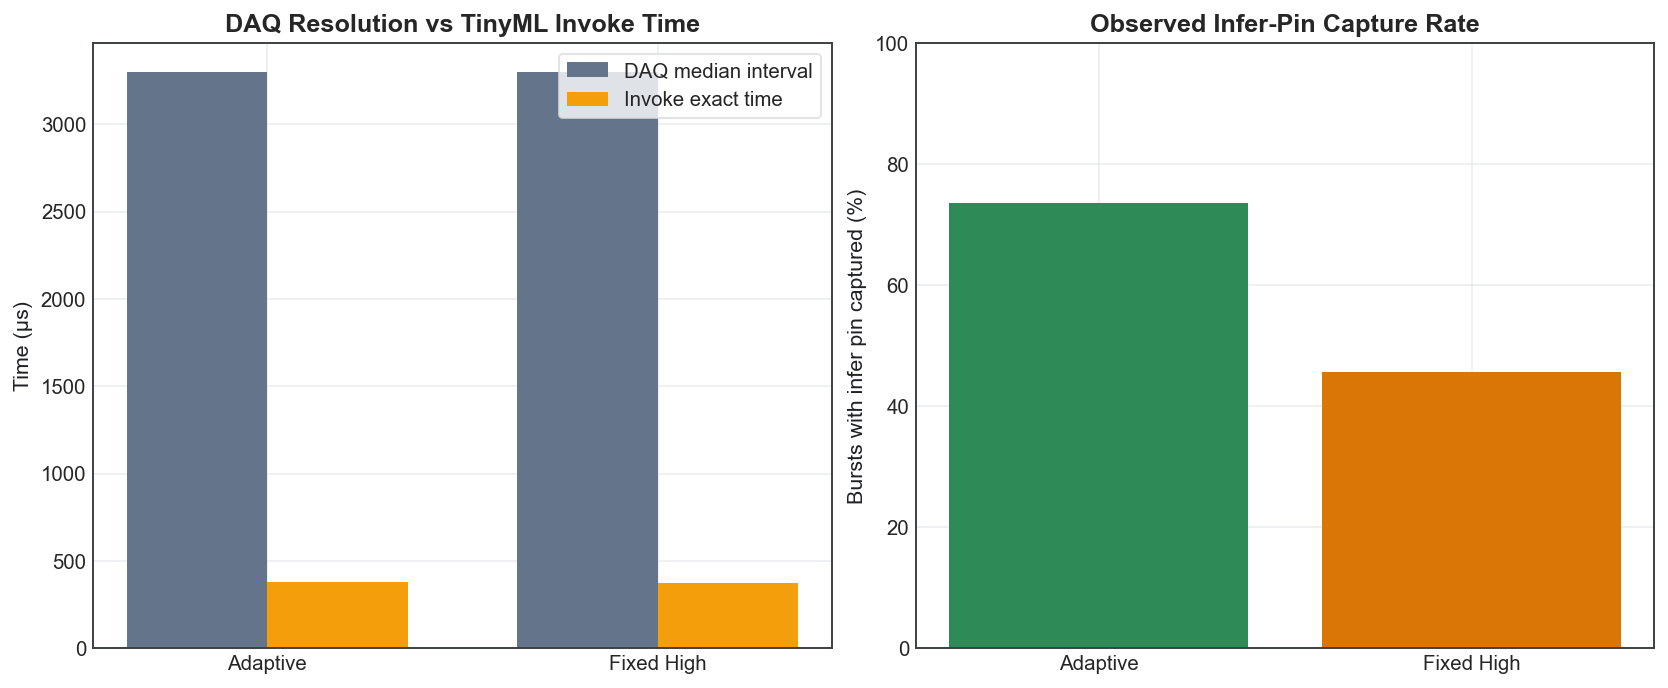

In [5]:
fig = micro_lib.plot_timing_resolution_dashboard(mode_summary_df)
fig.savefig(OUTPUT_DIR / "micro_timing_resolution_v7.png", bbox_inches="tight")
plt.show()


Representative burst


,mode_id,mode_name,run_name,burst_index,seed_start_idx,seed_end_idx,integration_start_idx,integration_end_idx,seed_start_us,seed_end_us,...,dsp_hr_bpm,peak_bpm_target,ac_target,std_hp_target,ptp_hp_target,quality_reason,ai_energy_est_uj,dsp_energy_est_uj,ai_energy_fraction_pct,infer_captured
45,1,fixed_high,fixed_high_1,7,6934,6937,6934,6941,22620831,22630727,...,NaN,67.5,0.059,1723.0,14200.8,3.0,31.416,1452.97,2.116431,True


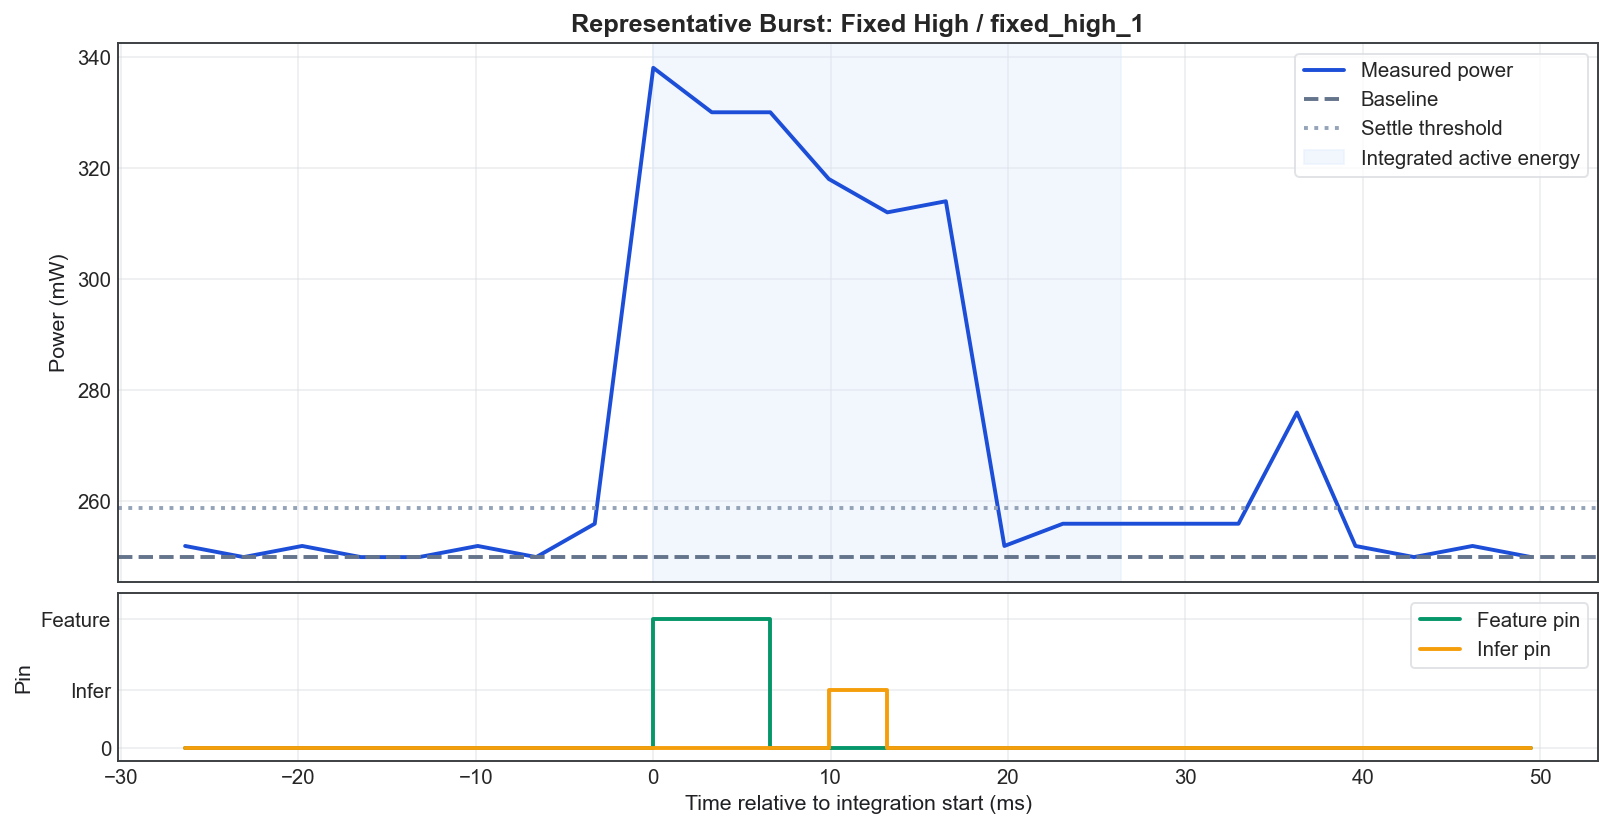

In [6]:
representative_burst = micro_lib.pick_representative_burst(
    burst_df,
    prefer_mode="fixed_high",
    require_infer_capture=True,
)
run_key = (representative_burst["mode_name"], representative_burst["run_name"])
representative_run = analysis["runs"][run_key]

print("Representative burst")
display(representative_burst.to_frame().T.round(2))

fig = micro_lib.plot_representative_burst(representative_burst, representative_run)
fig.savefig(OUTPUT_DIR / "representative_burst_v7.png", bbox_inches="tight")
plt.show()


C:\Users\nguye\AppData\Local\Temp\ipykernel_15636\2004520257.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


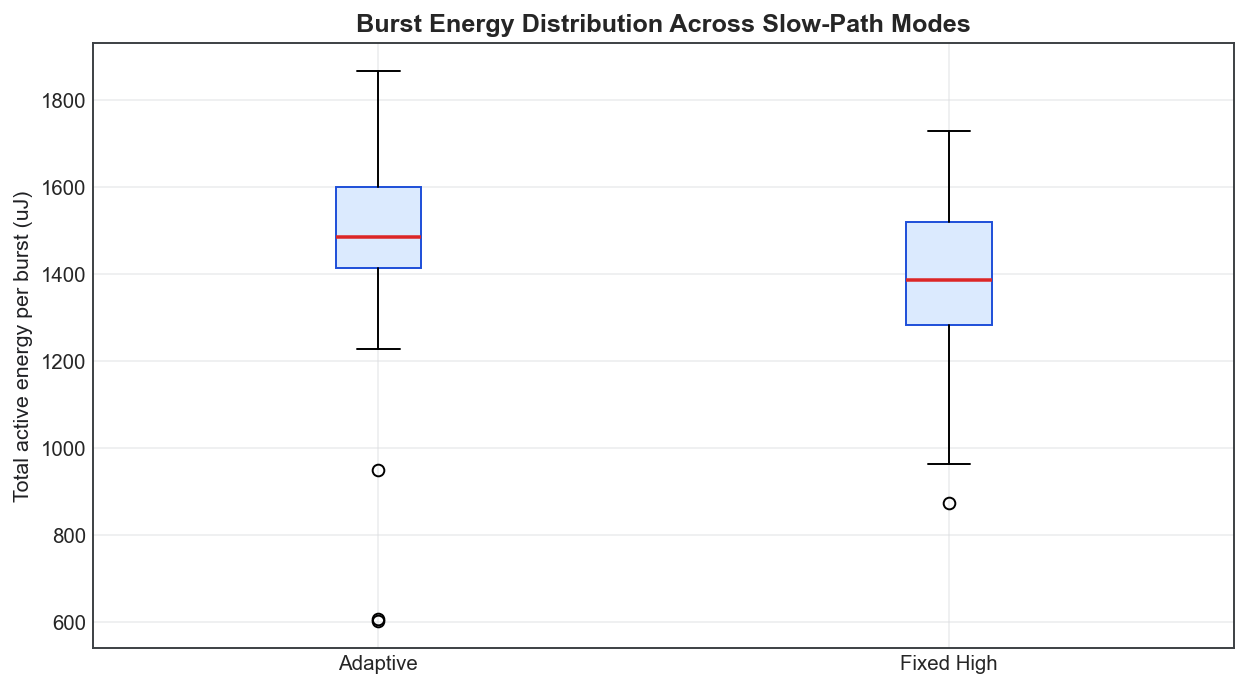

In [7]:
burst_distribution_df = burst_df.copy()
burst_distribution_df["mode_label"] = burst_distribution_df["mode_name"].map(micro_lib.MODE_LABELS)

fig, ax = plt.subplots(figsize=(8.8, 4.8), constrained_layout=True)
box_data = [
    burst_distribution_df.loc[burst_distribution_df["mode_name"] == mode, "total_active_energy_uj"].to_numpy()
    for mode in ["adaptive", "fixed_high"]
]
ax.boxplot(
    box_data,
    labels=[micro_lib.MODE_LABELS["adaptive"], micro_lib.MODE_LABELS["fixed_high"]],
    patch_artist=True,
    boxprops={"facecolor": "#DBEAFE", "edgecolor": "#1D4ED8"},
    medianprops={"color": "#DC2626", "linewidth": 1.8},
)
ax.set_ylabel("Total active energy per burst (uJ)")
ax.set_title("Burst Energy Distribution Across Slow-Path Modes")
fig.savefig(OUTPUT_DIR / "burst_energy_distribution_v7.png", bbox_inches="tight")
plt.show()


In [8]:
run_summary_df.to_csv(OUTPUT_DIR / "run_summary_v7.csv", index=False)
burst_df.to_csv(OUTPUT_DIR / "burst_summary_v7.csv", index=False)
mode_summary_df.to_csv(OUTPUT_DIR / "mode_summary_v7.csv", index=False)

print("Saved CSV artifacts:")
print("-", OUTPUT_DIR / "run_summary_v7.csv")
print("-", OUTPUT_DIR / "burst_summary_v7.csv")
print("-", OUTPUT_DIR / "mode_summary_v7.csv")


Saved CSV artifacts:
- c:\ml\kaggle-ml-basics\artifacts\ppg_hr_micro_analysis_v7\run_summary_v7.csv
- c:\ml\kaggle-ml-basics\artifacts\ppg_hr_micro_analysis_v7\burst_summary_v7.csv
- c:\ml\kaggle-ml-basics\artifacts\ppg_hr_micro_analysis_v7\mode_summary_v7.csv
